# Phase 3 : Analyse Non Supervisée et Labellisation Faible

Ce notebook implémente le skill `brainscan-unsupervised-analysis`.
Il vise à explorer la structure des embeddings extraits via ResNet50 en utilisant des techniques de réduction de dimension et de clustering.

**Objectifs :**
1. Charger les embeddings.
2. Appliquer une PCA pour réduire la complexité.
3. Visualiser les regroupements naturels via t-SNE.
4. Appliquer un clustering K-Means pour la labellisation faible.
5. Évaluer la qualité du clustering via le score ARI (Adjusted Rand Index).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="bright")

## 1. Chargement des embeddings
On charge le fichier `.npy` généré à l'étape précédente.

In [2]:
features_path = "../data/features_brainscan.npy"
if not os.path.exists(features_path):
    raise FileNotFoundError(f"Le fichier {features_path} est introuvable. Veuillez lancer l'étape 2 d'abord.")

data = np.load(features_path, allow_pickle=True).item()
X = data["features"]
filenames = data["filenames"]
labels = data["labels"]

print(f"✅ {len(X)} embeddings chargés.")
print(f"Dimension initiale : {X.shape[1]}")

✅ 1506 embeddings chargés.
Dimension initiale : 2048


## 2. Standardisation et PCA
La PCA permet de réduire le bruit et d'accélérer les calculs t-SNE ultérieurs en conservant 95% de la variance.

In [3]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Nombre de composantes PCA pour 95% de variance : {X_pca.shape[1]}")

Nombre de composantes PCA pour 95% de variance : 265


## 3. Visualisation t-SNE
Visualisation en 2D pour observer si les labels 'Normal' et 'Cancer' forment des clusters distincts naturellement.

⏳ Exécution du t-SNE (cela peut prendre quelques minutes)...


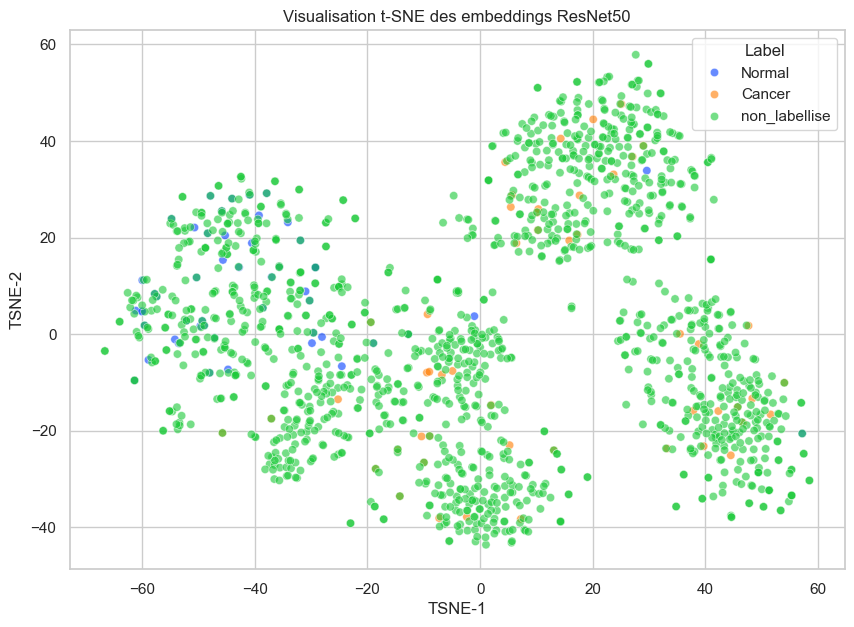

In [4]:
print("⏳ Exécution du t-SNE (cela peut prendre quelques minutes)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

df_tsne = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Label': labels
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_tsne, x='TSNE-1', y='TSNE-2', hue='Label', alpha=0.6, palette='bright')
plt.title("Visualisation t-SNE des embeddings ResNet50")
plt.show()

## 4. Clustering K-Means
On applique K-Means sur les deux premières dimensions du t-SNE (ou sur les composantes PCA) pour une labellisation faible.

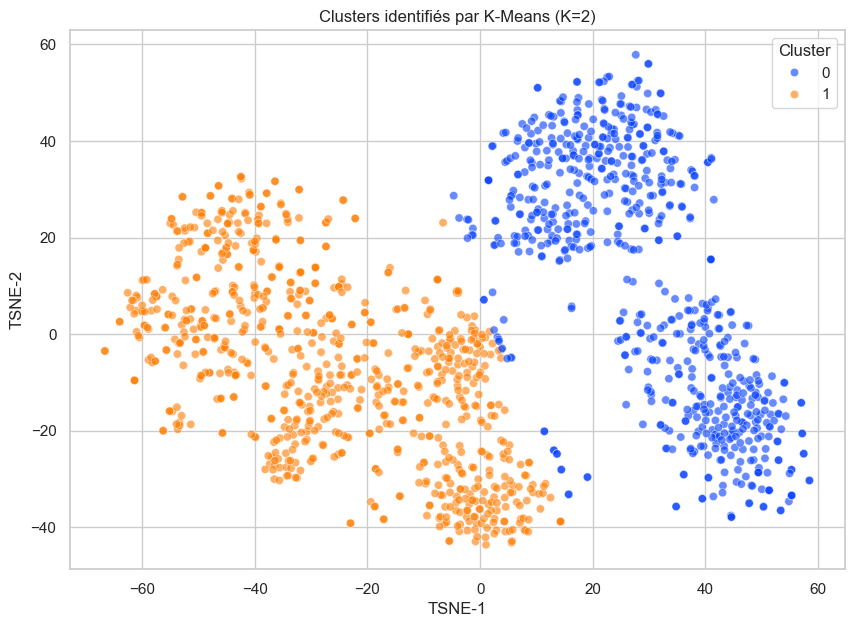

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_tsne['Cluster'] = kmeans.fit_predict(X_tsne)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_tsne, x='TSNE-1', y='TSNE-2', hue='Cluster', alpha=0.6, palette='bright')
plt.title("Clusters identifiés par K-Means (K=2)")
plt.show()

## 5. Évaluation par Score ARI
L'Adjusted Rand Index (ARI) mesure la similarité entre les clusters prédits et les labels réels (Hospitaliers) sur le sous-ensemble labellisé.

In [6]:
# On ne garde que les données labellisées pour l'évaluation
labeled_mask = (df_tsne['Label'] != 'non_labellise') & (df_tsne['Label'] != 'sans_label')
y_true = df_tsne[labeled_mask]['Label']
y_pred = df_tsne[labeled_mask]['Cluster']

ari_score = adjusted_rand_score(y_true, y_pred)
print(f"Score ARI (Adjusted Rand Index) : {ari_score:.4f}")
print("Note : Un score proche de 1 indique un clustering parfait, proche de 0 indique un clustering aléatoire.")

Score ARI (Adjusted Rand Index) : 0.3075
Note : Un score proche de 1 indique un clustering parfait, proche de 0 indique un clustering aléatoire.
